# Problem Set B — Data and Simulation (Weeks 3–4)

**Course:** Programming and Numerical Methods for Economics (ECNM10115)
**University of Edinburgh**

**This version includes solutions.**

### Grading Summary

| Question | Topic | Marks |
|:--------:|:------|:-----:|
| 1 | Building and exploring a DataFrame | 10 |
| 2 | Dummies, missing values, and data cleaning | 10 |
| 3 | Random numbers and distributions | 10 |
| 4 | Monte Carlo integration | 10 |
| 5 | AR(1) processes | 10 |
| 6 | Markov chains | 10 |
| 7 | Merging and reshaping DataFrames | 10 |
| 8 | Bootstrap confidence intervals | 10 |
| 9 | Variance reduction: antithetic variates | 10 |
| 10 | Regime-switching GDP simulation (capstone) | 10 |
| **Total** | | **100** |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

---
## Question 1 — Building and Exploring a DataFrame [10 marks]

A researcher collects the following data on six European economies (2023 estimates):

| Country | GDP (\$bn) | Population (m) | Unemployment (%) |
|---------|-----------|----------------|-------------------|
| Germany | 4430 | 83.2 | 3.0 |
| France | 3050 | 67.8 | 7.1 |
| Italy | 2190 | 59.0 | 7.6 |
| Spain | 1580 | 47.4 | 11.7 |
| Netherlands | 1090 | 17.6 | 3.5 |
| Sweden | 590 | 10.5 | 7.5 |

**(a)** [2 marks] Create a pandas DataFrame from the table above with columns `'Country'`, `'GDP'`, `'Population'`, and `'Unemployment'`. Set `'Country'` as the index.

**(b)** [2 marks] Using `.loc`, select the GDP and Unemployment columns for Germany, Italy, and Sweden. Using `.iloc`, select the first three rows and the last two columns.

**(c)** [3 marks] Add a new column `'GDP_per_capita'` equal to GDP (in billions) divided by Population (in millions), giving units of thousands of dollars per person. Then subset the DataFrame to keep only countries where GDP per capita exceeds \$30{,}000 and unemployment is below 5%.

**(d)** [3 marks] Compute the mean and standard deviation of GDP per capita across all six countries. Print a formatted summary: `"Mean GDP per capita: $XX.X thousand; Std dev: $XX.X thousand"`. Identify which country has the highest GDP per capita.

In [2]:
# --- Solution ---
# (a)
data = {
    'Country': ['Germany', 'France', 'Italy', 'Spain', 'Netherlands', 'Sweden'],
    'GDP': [4430, 3050, 2190, 1580, 1090, 590],
    'Population': [83.2, 67.8, 59.0, 47.4, 17.6, 10.5],
    'Unemployment': [3.0, 7.1, 7.6, 11.7, 3.5, 7.5]
}
df = pd.DataFrame(data)
df = df.set_index('Country')
print(df)
print()

# (b)
print("--- .loc selection ---")
print(df.loc[['Germany', 'Italy', 'Sweden'], ['GDP', 'Unemployment']])
print()
print("--- .iloc selection ---")
print(df.iloc[:3, -2:])
print()

# (c)
df['GDP_per_capita'] = df['GDP'] / df['Population']  # thousands of $ per person
print("DataFrame with GDP per capita:")
print(df)
print()

rich_low_unemp = df[(df['GDP_per_capita'] > 30) & (df['Unemployment'] < 5)]
print("Countries with GDP per capita > $30k and unemployment < 5%:")
print(rich_low_unemp)
print()

# (d)
mean_gdppc = df['GDP_per_capita'].mean()
std_gdppc = df['GDP_per_capita'].std()
print(f"Mean GDP per capita: ${mean_gdppc:.1f} thousand; Std dev: ${std_gdppc:.1f} thousand")

top = df['GDP_per_capita'].idxmax()
print(f"Highest GDP per capita: {top} (${df.loc[top, 'GDP_per_capita']:.1f} thousand)")

              GDP  Population  Unemployment
Country                                    
Germany      4430        83.2           3.0
France       3050        67.8           7.1
Italy        2190        59.0           7.6
Spain        1580        47.4          11.7
Netherlands  1090        17.6           3.5
Sweden        590        10.5           7.5

--- .loc selection ---
          GDP  Unemployment
Country                    
Germany  4430           3.0
Italy    2190           7.6
Sweden    590           7.5

--- .iloc selection ---
         Population  Unemployment
Country                          
Germany        83.2           3.0
France         67.8           7.1
Italy          59.0           7.6

DataFrame with GDP per capita:
              GDP  Population  Unemployment  GDP_per_capita
Country                                                    
Germany      4430        83.2           3.0       53.245192
France       3050        67.8           7.1       44.985251
Italy        2190

---
## Question 2 — Dummies, Missing Values, and Data Cleaning [10 marks]

A household survey records income, education level, region, and number of children for 10 households. Some entries are missing.

**(a)** [2 marks] Create the following DataFrame (use `np.nan` for missing values):

| HouseholdID | Income | Education | Region | Children |
|-------------|--------|-----------|--------|----------|
| 1 | 35000 | Secondary | North | 2 |
| 2 | 52000 | University | South | 1 |
| 3 | NaN | Secondary | North | 3 |
| 4 | 41000 | Postgrad | South | NaN |
| 5 | 28000 | Secondary | NaN | 2 |
| 6 | 67000 | University | North | 0 |
| 7 | NaN | Postgrad | South | 1 |
| 8 | 45000 | NaN | North | 2 |
| 9 | 31000 | Secondary | South | 4 |
| 10 | 58000 | University | North | NaN |

**(b)** [2 marks] Use `pd.get_dummies()` to create dummy variables for the `'Education'` column (drop the first category to avoid the dummy-variable trap). Concatenate the dummies with the original DataFrame and drop the original `'Education'` column.

**(c)** [2 marks] Report the number and percentage of missing values in each column. Then fill missing `'Income'` values with the column median and missing `'Children'` values with the column mode (most frequent value). Drop any rows that still have missing values after imputation.

**(d)** [2 marks] From the cleaned DataFrame, select only households in the `'North'` region with income above \$40{,}000.

**(e)** [2 marks] Compute the mean income grouped by region. Print the result and briefly comment (in a print statement or markdown) on which region has higher average income in this sample.

In [3]:
# --- Solution ---
# (a)
survey = pd.DataFrame({
    'HouseholdID': range(1, 11),
    'Income': [35000, 52000, np.nan, 41000, 28000, 67000, np.nan, 45000, 31000, 58000],
    'Education': ['Secondary', 'University', 'Secondary', 'Postgrad', 'Secondary',
                  'University', 'Postgrad', np.nan, 'Secondary', 'University'],
    'Region': ['North', 'South', 'North', 'South', np.nan, 'North', 'South', 'North', 'South', 'North'],
    'Children': [2, 1, 3, np.nan, 2, 0, 1, 2, 4, np.nan]
})
survey = survey.set_index('HouseholdID')
print(survey)
print()

# (b)
dummies = pd.get_dummies(survey['Education'], drop_first=True, dtype=int)
survey = pd.concat([survey, dummies], axis=1)
survey = survey.drop(columns='Education')
print("After adding dummies:")
print(survey)
print()

# (c)
print("Missing values per column:")
print(survey.isna().sum())
print()
print("Percentage missing:")
print((survey.isna().mean() * 100).round(1))
print()

survey['Income'] = survey['Income'].fillna(survey['Income'].median())
survey['Children'] = survey['Children'].fillna(survey['Children'].mode()[0])
survey = survey.dropna()
print("After imputation and dropping remaining NaNs:")
print(survey)
print()

# (d)
north_high = survey[(survey['Region'] == 'North') & (survey['Income'] > 40000)]
print("North region, income > $40,000:")
print(north_high)
print()

# (e)
mean_by_region = survey.groupby('Region')['Income'].mean()
print("Mean income by region:")
print(mean_by_region)
print()
top_region = mean_by_region.idxmax()
print(f"In this sample, the {top_region} region has higher average income "
      f"(${mean_by_region[top_region]:,.0f}).")

              Income   Education Region  Children
HouseholdID                                      
1            35000.0   Secondary  North       2.0
2            52000.0  University  South       1.0
3                NaN   Secondary  North       3.0
4            41000.0    Postgrad  South       NaN
5            28000.0   Secondary    NaN       2.0
6            67000.0  University  North       0.0
7                NaN    Postgrad  South       1.0
8            45000.0         NaN  North       2.0
9            31000.0   Secondary  South       4.0
10           58000.0  University  North       NaN

After adding dummies:
              Income Region  Children  Secondary  University
HouseholdID                                                 
1            35000.0  North       2.0          1           0
2            52000.0  South       1.0          0           1
3                NaN  North       3.0          1           0
4            41000.0  South       NaN          0           0
5          

---
## Question 3 — Random Numbers and Distributions [10 marks]

**(a)** [3 marks] Draw $n = 10{,}000$ samples from a $\text{Normal}(\mu=5,\, \sigma=2)$ distribution. Compute the sample mean and standard deviation. Print them alongside the theoretical values. Plot a histogram of the draws with 50 bins and overlay the true probability density function (PDF) using `scipy.stats.norm` or by coding the formula directly.

**(b)** [4 marks] If $X \sim \text{Normal}(\mu, \sigma^2)$, then $Y = e^X$ follows a log-normal distribution. Using your draws from part (a), compute $Y = e^X$. Plot a histogram of $Y$ (use 100 bins and set `density=True`). Compute the sample mean of $Y$ and compare it to the theoretical mean $E[Y] = e^{\mu + \sigma^2/2}$. Explain in a comment or markdown cell why the sample mean may deviate noticeably from the theoretical mean.

**(c)** [3 marks] A simple macroeconomic model assigns the following probabilities to next quarter's GDP growth:

| Growth | $-2\%$ | $0\%$ | $1\%$ | $3\%$ |
|--------|--------|-------|-------|-------|
| Probability | 0.10 | 0.25 | 0.40 | 0.25 |

Simulate 10,000 quarters of GDP growth by drawing from this discrete distribution using `np.random.choice`. Compute the simulated expected growth rate and variance, and compare them to the exact theoretical values $E[g]$ and $\text{Var}(g)$.

Sample mean:  4.9957  (theoretical: 5)
Sample std:   2.0068  (theoretical: 2)



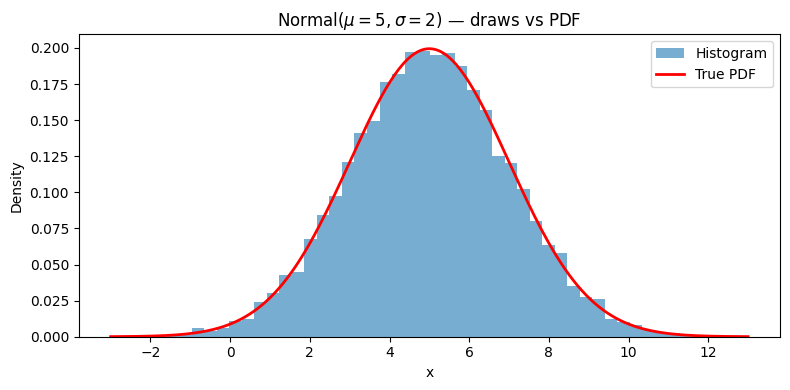

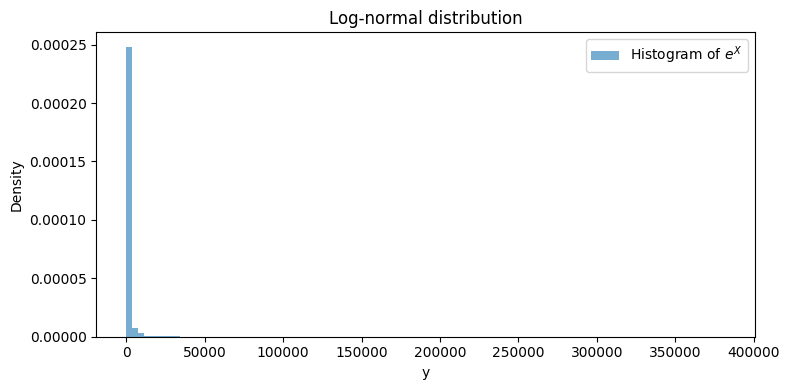

Sample mean of Y:      1118.42
Theoretical E[Y]:      1096.63

Simulated E[g]:   0.9738   (theoretical: 0.9500)
Simulated Var(g): 2.1789   (theoretical: 2.1475)


In [4]:
# --- Solution ---
from scipy.stats import norm

# (a)
mu, sigma = 5, 2
X = np.random.normal(mu, sigma, size=10_000)
print(f"Sample mean:  {X.mean():.4f}  (theoretical: {mu})")
print(f"Sample std:   {X.std():.4f}  (theoretical: {sigma})")
print()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X, bins=50, density=True, alpha=0.6, label='Histogram')
x_grid = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), 'r-', lw=2, label='True PDF')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Normal($\mu=5, \sigma=2$) — draws vs PDF')
ax.legend()
plt.tight_layout()
plt.show()

# (b)
Y = np.exp(X)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(Y, bins=100, density=True, alpha=0.6, label='Histogram of $e^X$')
ax.set_xlabel('y')
ax.set_ylabel('Density')
ax.set_title('Log-normal distribution')
ax.legend()
plt.tight_layout()
plt.show()

theoretical_mean_Y = np.exp(mu + sigma**2 / 2)
print(f"Sample mean of Y:      {Y.mean():.2f}")
print(f"Theoretical E[Y]:      {theoretical_mean_Y:.2f}")
print()
# The log-normal distribution is heavily right-skewed, so the sample mean
# is sensitive to a few very large draws. With finite samples the sample
# mean can deviate noticeably from the theoretical mean.

# (c)
growth_vals = np.array([-2, 0, 1, 3])
probs = np.array([0.10, 0.25, 0.40, 0.25])

sim_growth = np.random.choice(growth_vals, size=10_000, p=probs)

E_g = (growth_vals * probs).sum()
E_g2 = (growth_vals**2 * probs).sum()
Var_g = E_g2 - E_g**2

print(f"Simulated E[g]:   {sim_growth.mean():.4f}   (theoretical: {E_g:.4f})")
print(f"Simulated Var(g): {sim_growth.var():.4f}   (theoretical: {Var_g:.4f})")

---
## Question 4 — Monte Carlo Integration [10 marks]

Suppose we want to estimate

$$\theta = E[g(X)] = \int_{-\infty}^{\infty} g(x)\, f(x)\, dx$$

where $X \sim \text{Normal}(0,1)$ and $g(x) = x^2 + \sin(x)$.

**(a)** [3 marks] Write a function `mc_estimate(g, n)` that draws $n$ samples from $\text{Normal}(0,1)$, evaluates $g$ at each draw, and returns the sample mean as an estimate of $\theta$. Use it to estimate $\theta$ with $n = 100{,}000$.

**(b)** [4 marks] Investigate how the Monte Carlo estimate converges as $n$ grows. For $n \in \{100, 500, 1000, 5000, 10{\,}000, 50{\,}000, 100{\,}000\}$, compute the MC estimate (use a fresh set of draws each time). Plot the estimates against $n$ on a log-scaled $x$-axis and draw a horizontal line at the true value. The true value is $E[X^2] + E[\sin(X)] = 1 + e^{-1/2}\sin(1) \approx 1 + 0.5109$. *(Hint: $E[\sin(X)]$ for $X\sim N(0,1)$ equals $e^{-1/2}\sin(1)$ by the moment-generating-function identity.)*

**(c)** [3 marks] For $n = 10{,}000$, repeat the MC estimation $M = 1{,}000$ times (each time with independent draws). Plot a histogram of the 1,000 estimates and compute a 95% confidence interval from the 2.5th and 97.5th percentiles. Verify that the true value falls inside this interval.

MC estimate (n=100,000): 1.001758
True value:              1.510378



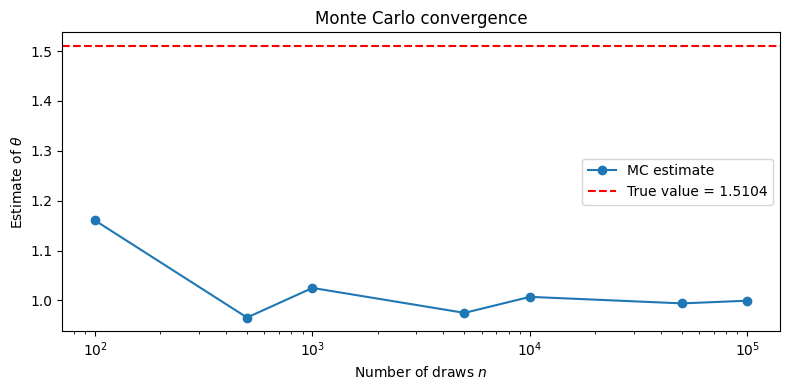

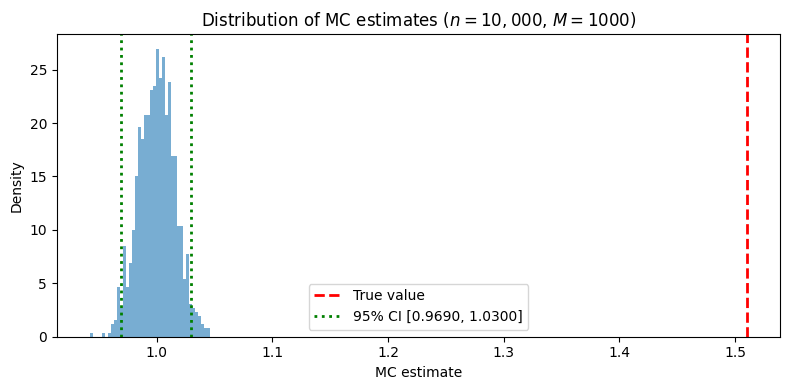

95% CI: [0.9690, 1.0300]
True value inside CI: False


In [5]:
# --- Solution ---
# (a)
def g(x):
    return x**2 + np.sin(x)

def mc_estimate(g, n):
    draws = np.random.normal(0, 1, size=n)
    return g(draws).mean()

theta_hat = mc_estimate(g, 100_000)
theta_true = 1 + np.exp(-0.5) * np.sin(1)
print(f"MC estimate (n=100,000): {theta_hat:.6f}")
print(f"True value:              {theta_true:.6f}")
print()

# (b)
ns = [100, 500, 1000, 5000, 10_000, 50_000, 100_000]
estimates = [mc_estimate(g, n) for n in ns]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns, estimates, 'o-', label='MC estimate')
ax.axhline(theta_true, color='r', ls='--', label=f'True value = {theta_true:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Number of draws $n$')
ax.set_ylabel('Estimate of $\\theta$')
ax.set_title('Monte Carlo convergence')
ax.legend()
plt.tight_layout()
plt.show()

# (c)
M = 1000
n = 10_000
replications = np.array([mc_estimate(g, n) for _ in range(M)])

ci_low = np.percentile(replications, 2.5)
ci_high = np.percentile(replications, 97.5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(replications, bins=40, density=True, alpha=0.6)
ax.axvline(theta_true, color='r', ls='--', lw=2, label='True value')
ax.axvline(ci_low, color='green', ls=':', lw=2, label=f'95% CI [{ci_low:.4f}, {ci_high:.4f}]')
ax.axvline(ci_high, color='green', ls=':', lw=2)
ax.set_xlabel('MC estimate')
ax.set_ylabel('Density')
ax.set_title(f'Distribution of MC estimates ($n={n:,}$, $M={M}$)')
ax.legend()
plt.tight_layout()
plt.show()

inside = ci_low <= theta_true <= ci_high
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"True value inside CI: {inside}")

---
## Question 5 — AR(1) Processes [10 marks]

An AR(1) process is defined by

$$y_t = \rho\, y_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, \sigma^2),$$

with $y_0 = 0$.

**(a)** [3 marks] Write a function `simulate_ar1(rho, sigma, T)` that returns an array of length $T$ containing a simulated path of the AR(1) process. Simulate and plot two paths of length $T = 200$: one with $\rho = 0.8,\, \sigma = 1$ (stationary) and one with $\rho = 1.0,\, \sigma = 1$ (unit root / random walk). Plot them on the same figure with a legend.

**(b)** [4 marks] For the stationary case ($\rho = 0.8$), the unconditional variance is $\text{Var}(y) = \sigma^2 / (1 - \rho^2)$. Simulate $R = 500$ independent paths of length $T = 500$. For each path, compute the sample variance of $y_t$. Plot a histogram of the 500 sample variances and draw a vertical line at the theoretical variance. Comment on the distribution.

**(c)** [3 marks] Using one long simulation ($T = 5{,}000$, $\rho = 0.8$), compute the sample autocorrelation at lags 1 through 10. Compare these to the theoretical autocorrelations $\rho^k$ for $k = 1, \dots, 10$ by plotting both on the same bar chart.

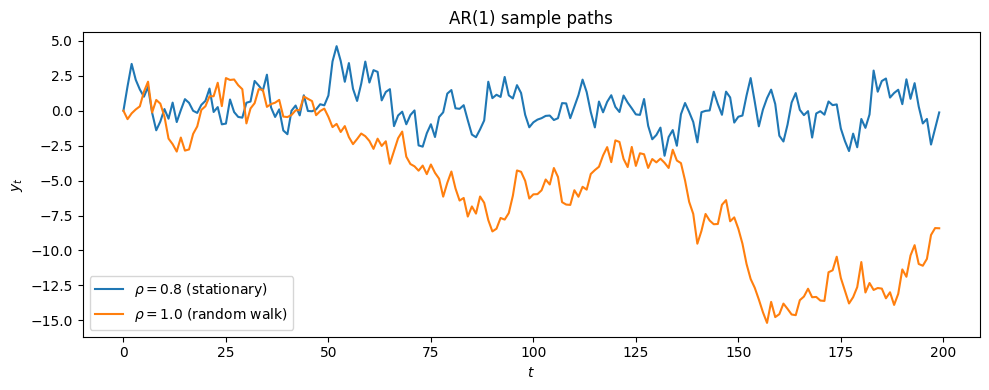

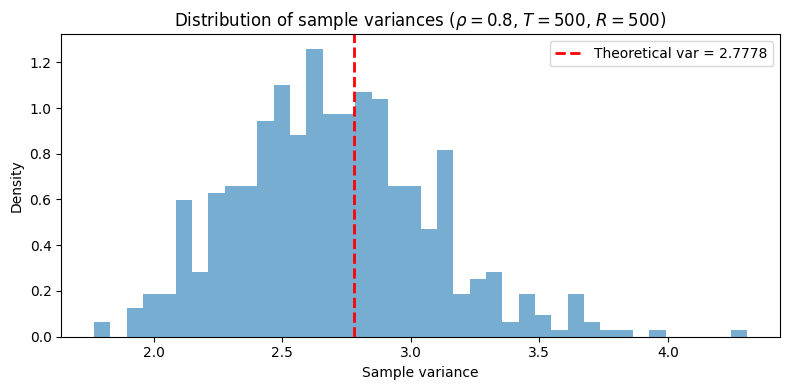

Mean of sample variances: 2.6995
Theoretical variance:     2.7778



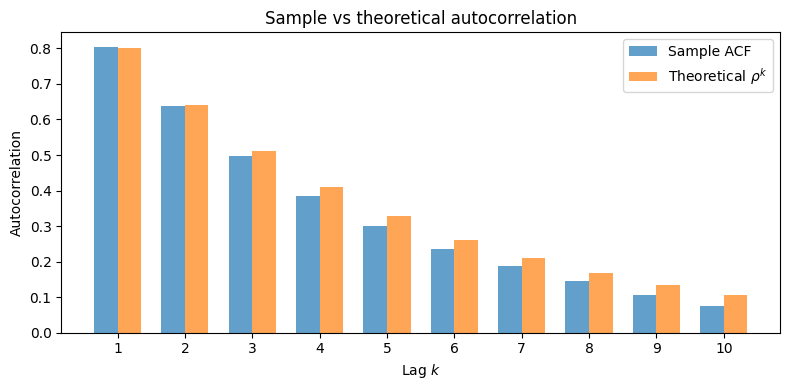

In [6]:
# --- Solution ---
# (a)
def simulate_ar1(rho, sigma, T):
    y = np.zeros(T)
    eps = np.random.normal(0, sigma, size=T)
    for t in range(1, T):
        y[t] = rho * y[t-1] + eps[t]
    return y

T = 200
y_stat = simulate_ar1(0.8, 1.0, T)
y_rw   = simulate_ar1(1.0, 1.0, T)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_stat, label='$\\rho = 0.8$ (stationary)')
ax.plot(y_rw,   label='$\\rho = 1.0$ (random walk)')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
ax.set_title('AR(1) sample paths')
ax.legend()
plt.tight_layout()
plt.show()

# (b)
rho, sigma = 0.8, 1.0
T, R = 500, 500
theoretical_var = sigma**2 / (1 - rho**2)

sample_vars = np.array([simulate_ar1(rho, sigma, T).var() for _ in range(R)])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sample_vars, bins=40, density=True, alpha=0.6)
ax.axvline(theoretical_var, color='r', ls='--', lw=2,
           label=f'Theoretical var = {theoretical_var:.4f}')
ax.set_xlabel('Sample variance')
ax.set_ylabel('Density')
ax.set_title(f'Distribution of sample variances ($\\rho={rho}$, $T={T}$, $R={R}$)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean of sample variances: {sample_vars.mean():.4f}")
print(f"Theoretical variance:     {theoretical_var:.4f}")
# The distribution is right-skewed because variance is non-negative and
# estimated from a dependent (autocorrelated) series.
print()

# (c)
T_long = 5000
y_long = simulate_ar1(0.8, 1.0, T_long)

lags = np.arange(1, 11)
y_dm = y_long - y_long.mean()
gamma0 = np.dot(y_dm, y_dm) / T_long
sample_acf = np.array([np.dot(y_dm[k:], y_dm[:-k]) / T_long / gamma0 for k in lags])
theoretical_acf = rho ** lags

width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lags - width/2, sample_acf, width, label='Sample ACF', alpha=0.7)
ax.bar(lags + width/2, theoretical_acf, width, label='Theoretical $\\rho^k$', alpha=0.7)
ax.set_xlabel('Lag $k$')
ax.set_ylabel('Autocorrelation')
ax.set_title('Sample vs theoretical autocorrelation')
ax.set_xticks(lags)
ax.legend()
plt.tight_layout()
plt.show()

---
## Question 6 — Markov Chains [10 marks]

Consider a two-state Markov chain model of the business cycle with states $S = \{\text{Expansion}, \text{Recession}\}$ and transition matrix

$$P = \begin{pmatrix} 0.90 & 0.10 \\ 0.30 & 0.70 \end{pmatrix},$$

where $P_{ij}$ is the probability of moving from state $i$ to state $j$.

**(a)** [2 marks] Using the `quantecon` library, create a `MarkovChain` object from the transition matrix $P$. Compute and print the stationary distribution $\pi$ using `mc.stationary_distributions`.

**(b)** [3 marks] Simulate a path of length $T = 5{,}000$ starting from state 0 (Expansion). Plot the state over time (use 0 for Expansion and 1 for Recession). Compute the fraction of time spent in each state and compare to the stationary distribution.

**(c)** [3 marks] Assign GDP growth rates of $+2\%$ in Expansion and $-1\%$ in Recession. Using your simulated state path, construct the time series of GDP growth. Starting from $\text{GDP}_0 = 100$, compute the GDP level path: $\text{GDP}_t = \text{GDP}_{t-1} \times (1 + g_t / 100)$. Plot the GDP level over time.

**(d)** [2 marks] Compute the long-run average GDP growth rate from your simulation and compare it to the theoretical value implied by the stationary distribution, $\bar{g} = \pi_0 \times 2 + \pi_1 \times (-1)$.

Stationary distribution:
  Expansion: 0.7500
  Recession: 0.2500



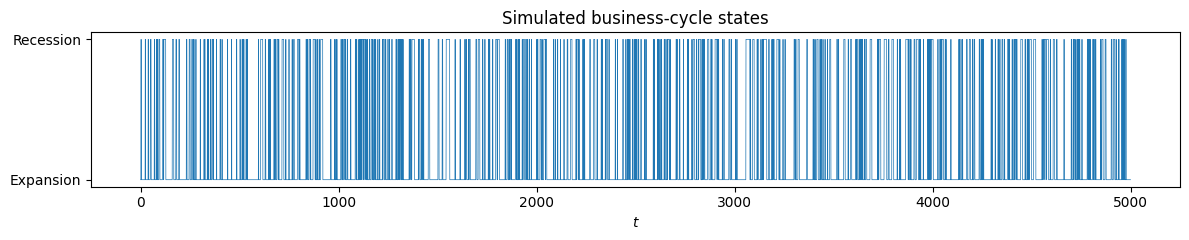

Fraction in Expansion: 0.7540  (stationary: 0.7500)
Fraction in Recession: 0.2460  (stationary: 0.2500)



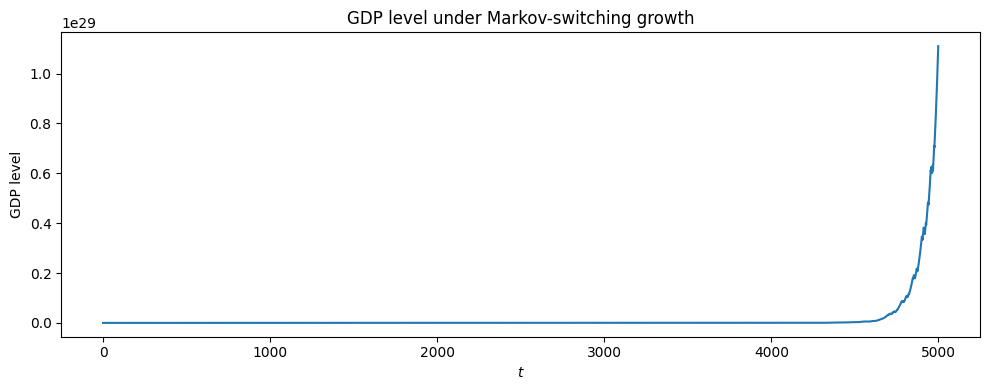

Simulated average growth: 1.2620%
Theoretical average growth: 1.2500%


In [7]:
# --- Solution ---
import quantecon as qe

# (a)
P = np.array([[0.90, 0.10],
              [0.30, 0.70]])
mc = qe.MarkovChain(P, state_values=['Expansion', 'Recession'])

pi = mc.stationary_distributions[0]
print("Stationary distribution:")
print(f"  Expansion: {pi[0]:.4f}")
print(f"  Recession: {pi[1]:.4f}")
print()

# (b)
T = 5000
states = mc.simulate(ts_length=T, init='Expansion')

fig, ax = plt.subplots(figsize=(12, 2.5))
state_numeric = np.array([0 if s == 'Expansion' else 1 for s in states])
ax.plot(state_numeric, linewidth=0.5)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Expansion', 'Recession'])
ax.set_xlabel('$t$')
ax.set_title('Simulated business-cycle states')
plt.tight_layout()
plt.show()

frac_exp = (state_numeric == 0).mean()
frac_rec = (state_numeric == 1).mean()
print(f"Fraction in Expansion: {frac_exp:.4f}  (stationary: {pi[0]:.4f})")
print(f"Fraction in Recession: {frac_rec:.4f}  (stationary: {pi[1]:.4f})")
print()

# (c)
growth_rates = np.where(state_numeric == 0, 2.0, -1.0)
GDP = np.zeros(T)
GDP[0] = 100
for t in range(1, T):
    GDP[t] = GDP[t-1] * (1 + growth_rates[t] / 100)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(GDP)
ax.set_xlabel('$t$')
ax.set_ylabel('GDP level')
ax.set_title('GDP level under Markov-switching growth')
plt.tight_layout()
plt.show()

# (d)
avg_growth_sim = growth_rates.mean()
avg_growth_theory = pi[0] * 2 + pi[1] * (-1)
print(f"Simulated average growth: {avg_growth_sim:.4f}%")
print(f"Theoretical average growth: {avg_growth_theory:.4f}%")

---
## Question 7 — Merging and Reshaping DataFrames [10 marks]

You have two datasets. **Dataset A** contains annual GDP for four countries over 2019–2022:

| Country | Year | GDP (\$bn) |
|---------|------|-----------|
| Germany | 2019 | 3888 |
| Germany | 2020 | 3846 |
| Germany | 2021 | 4260 |
| Germany | 2022 | 4082 |
| France  | 2019 | 2729 |
| France  | 2020 | 2639 |
| France  | 2021 | 2958 |
| France  | 2022 | 2784 |
| Italy   | 2019 | 2005 |
| Italy   | 2020 | 1897 |
| Italy   | 2021 | 2114 |
| Italy   | 2022 | 2012 |
| Spain   | 2019 | 1394 |
| Spain   | 2020 | 1276 |
| Spain   | 2021 | 1427 |
| Spain   | 2022 | 1398 |

**Dataset B** contains total trade (exports + imports) for a partially overlapping set of countries:

| Country | Year | Trade (\$bn) |
|---------|------|-------------|
| Germany | 2019 | 2723 |
| Germany | 2020 | 2510 |
| Germany | 2021 | 2860 |
| Germany | 2022 | 3010 |
| France  | 2019 | 1198 |
| France  | 2020 | 1050 |
| France  | 2021 | 1250 |
| France  | 2022 | 1330 |
| UK      | 2019 | 1350 |
| UK      | 2020 | 1160 |
| UK      | 2021 | 1290 |
| UK      | 2022 | 1370 |

**(a)** [3 marks] Create the two DataFrames. Perform an **inner join**, a **left join**, and an **outer join** on `['Country', 'Year']`. Print the shape of each result and explain why they differ.

**(b)** [3 marks] Using the inner-joined DataFrame, compute a new column `Trade_to_GDP` (trade as a percentage of GDP). Then use `pd.pivot_table` to reshape this into a wide-format table with countries as rows and years as columns, showing `Trade_to_GDP` in each cell. Print the result.

**(c)** [2 marks] From the wide-format table produced in (b), compute the pairwise correlation matrix across countries (i.e., correlations of the `Trade_to_GDP` ratio over time). Print and interpret the result.

**(d)** [2 marks] Using Dataset A in long format, compute the year-on-year GDP growth rate (%) for each country. Which country experienced the largest GDP contraction in 2020? Which had the strongest recovery in 2021?

In [8]:
# --- Solution ---
# Create Dataset A
gdp_data = {
    'Country': ['Germany']*4 + ['France']*4 + ['Italy']*4 + ['Spain']*4,
    'Year': [2019,2020,2021,2022]*4,
    'GDP': [3888,3846,4260,4082, 2729,2639,2958,2784,
            2005,1897,2114,2012, 1394,1276,1427,1398]
}
df_gdp = pd.DataFrame(gdp_data)

# Create Dataset B
trade_data = {
    'Country': ['Germany']*4 + ['France']*4 + ['UK']*4,
    'Year': [2019,2020,2021,2022]*3,
    'Trade': [2723,2510,2860,3010, 1198,1050,1250,1330,
              1350,1160,1290,1370]
}
df_trade = pd.DataFrame(trade_data)

# (a)
inner = pd.merge(df_gdp, df_trade, on=['Country', 'Year'], how='inner')
left  = pd.merge(df_gdp, df_trade, on=['Country', 'Year'], how='left')
outer = pd.merge(df_gdp, df_trade, on=['Country', 'Year'], how='outer')

print(f"Inner join shape: {inner.shape}")   # only Germany & France (8 rows)
print(f"Left join shape:  {left.shape}")    # all of df_gdp (16 rows), NaN for missing trade
print(f"Outer join shape: {outer.shape}")   # all country-years from both (20 rows)
print()
# Inner: keeps only matching keys (Germany & France present in both).
# Left: keeps all rows from df_gdp; UK (in df_trade only) is dropped;
#   Italy & Spain get NaN in Trade.
# Outer: keeps everything; non-matching entries filled with NaN.

# (b)
inner['Trade_to_GDP'] = (inner['Trade'] / inner['GDP']) * 100

wide = pd.pivot_table(inner, values='Trade_to_GDP',
                      index='Country', columns='Year')
print("Trade-to-GDP ratio (%) — wide format:")
print(wide.round(2))
print()

# (c)
corr = wide.T.corr()
print("Pairwise correlation of Trade-to-GDP across years:")
print(corr.round(4))
print()
# Both countries show co-movement in trade openness relative to GDP,
# reflecting shared European economic shocks (e.g., COVID-19 in 2020).

# (d)
df_gdp = df_gdp.sort_values(['Country', 'Year'])
df_gdp['GDP_growth'] = df_gdp.groupby('Country')['GDP'].pct_change() * 100

print("GDP growth rates (%):")
print(df_gdp.dropna().to_string(index=False))
print()

growth_2020 = df_gdp[df_gdp['Year'] == 2020]
worst = growth_2020.loc[growth_2020['GDP_growth'].idxmin()]
print(f"Largest contraction in 2020: {worst['Country']} ({worst['GDP_growth']:.2f}%)")

growth_2021 = df_gdp[df_gdp['Year'] == 2021]
best = growth_2021.loc[growth_2021['GDP_growth'].idxmax()]
print(f"Strongest recovery in 2021: {best['Country']} ({best['GDP_growth']:.2f}%)")

Inner join shape: (8, 4)
Left join shape:  (16, 4)
Outer join shape: (20, 4)

Trade-to-GDP ratio (%) — wide format:
Year      2019   2020   2021   2022
Country                            
France   43.90  39.79  42.26  47.77
Germany  70.04  65.26  67.14  73.74

Pairwise correlation of Trade-to-GDP across years:
Country  France  Germany
Country                 
France   1.0000   0.9918
Germany  0.9918   1.0000

GDP growth rates (%):
Country  Year  GDP  GDP_growth
 France  2020 2639   -3.297911
 France  2021 2958   12.087912
 France  2022 2784   -5.882353
Germany  2020 3846   -1.080247
Germany  2021 4260   10.764431
Germany  2022 4082   -4.178404
  Italy  2020 1897   -5.386534
  Italy  2021 2114   11.439114
  Italy  2022 2012   -4.824976
  Spain  2020 1276   -8.464849
  Spain  2021 1427   11.833856
  Spain  2022 1398   -2.032235

Largest contraction in 2020: Spain (-8.46%)
Strongest recovery in 2021: France (12.09%)


---
## Question 8 — Bootstrap Confidence Intervals [10 marks]

The bootstrap is a resampling method for estimating the sampling distribution of a statistic. Given a sample $\{x_1, \dots, x_n\}$, we draw $B$ bootstrap samples (each of size $n$, drawn with replacement) and compute the statistic of interest on each bootstrap sample.

**(a)** [3 marks] Write a function `bootstrap_mean_ci(data, B=5000, alpha=0.05)` that:
1. Draws $B$ bootstrap samples (each of size $n =$ `len(data)`, with replacement).
2. Computes the sample mean of each bootstrap sample.
3. Returns the $\alpha/2$ and $1 - \alpha/2$ percentiles of the bootstrap means as the confidence interval.

Do **not** use any bootstrap library — implement from scratch using `np.random.choice`.

**(b)** [3 marks] Generate a skewed "income" sample: draw $n = 200$ observations from a log-normal distribution with parameters $\mu = 10.5$ and $\sigma = 0.8$ (i.e., `np.random.lognormal(10.5, 0.8, 200)`). Apply your bootstrap function with $B = 10{,}000$ to construct a 95% confidence interval for the population mean income.

**(c)** [2 marks] Compute the analytical (normal-approximation) 95% confidence interval: $\bar{x} \pm 1.96 \times s / \sqrt{n}$, where $\bar{x}$ is the sample mean and $s$ is the sample standard deviation. Compare this interval to the bootstrap CI. Comment on any differences — why might they arise for a skewed distribution?

**(d)** [2 marks] Plot the bootstrap sampling distribution (histogram of the $B$ bootstrap means). Mark the bootstrap CI bounds and the sample mean on the plot. Is the bootstrap distribution symmetric or skewed?

Sample mean income: $47,838
Bootstrap 95% CI:   [$42,336, $54,195]

Normal-approx 95% CI: [$41,932, $53,743]
Bootstrap 95% CI:     [$42,336, $54,195]



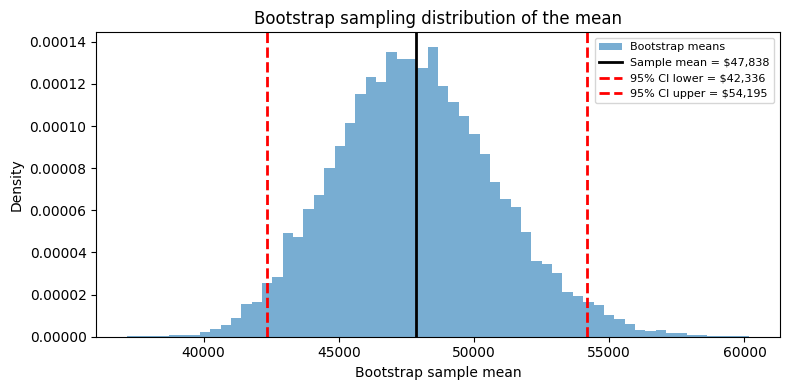

Skewness of bootstrap distribution: 0.2498
The bootstrap distribution is slightly right-skewed, reflecting
the skewness of the underlying log-normal income distribution.


In [9]:
# --- Solution ---
# (a)
def bootstrap_mean_ci(data, B=5000, alpha=0.05):
    n = len(data)
    boot_means = np.empty(B)
    for i in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means[i] = sample.mean()
    ci_lower = np.percentile(boot_means, 100 * alpha / 2)
    ci_upper = np.percentile(boot_means, 100 * (1 - alpha / 2))
    return ci_lower, ci_upper, boot_means

# (b)
income = np.random.lognormal(mean=10.5, sigma=0.8, size=200)
ci_low, ci_high, boot_means = bootstrap_mean_ci(income, B=10_000, alpha=0.05)

print(f"Sample mean income: ${income.mean():,.0f}")
print(f"Bootstrap 95% CI:   [${ci_low:,.0f}, ${ci_high:,.0f}]")
print()

# (c)
xbar = income.mean()
s = income.std(ddof=1)
n = len(income)
z = 1.96
ci_normal_low = xbar - z * s / np.sqrt(n)
ci_normal_high = xbar + z * s / np.sqrt(n)

print(f"Normal-approx 95% CI: [${ci_normal_low:,.0f}, ${ci_normal_high:,.0f}]")
print(f"Bootstrap 95% CI:     [${ci_low:,.0f}, ${ci_high:,.0f}]")
print()
# For skewed distributions the normal CI is symmetric around the sample mean,
# which may not reflect the actual sampling distribution. The bootstrap CI
# can be asymmetric, better capturing the skewness of the estimator's
# distribution. The normal approximation can also under-cover on the
# right tail for right-skewed data.

# (d)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_means, bins=60, density=True, alpha=0.6, label='Bootstrap means')
ax.axvline(xbar, color='black', ls='-', lw=2, label=f'Sample mean = ${xbar:,.0f}')
ax.axvline(ci_low, color='red', ls='--', lw=2, label=f'95% CI lower = ${ci_low:,.0f}')
ax.axvline(ci_high, color='red', ls='--', lw=2, label=f'95% CI upper = ${ci_high:,.0f}')
ax.set_xlabel('Bootstrap sample mean')
ax.set_ylabel('Density')
ax.set_title('Bootstrap sampling distribution of the mean')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

from scipy.stats import skew
print(f"Skewness of bootstrap distribution: {skew(boot_means):.4f}")
print("The bootstrap distribution is slightly right-skewed, reflecting")
print("the skewness of the underlying log-normal income distribution.")

---
## Question 9 — Variance Reduction: Antithetic Variates [10 marks]

When estimating $\theta = E[h(X)]$ by Monte Carlo, the **antithetic variates** method reduces variance by exploiting symmetry. For $X \sim N(0,1)$, instead of drawing $n$ independent samples, we draw $n/2$ samples $X_1, \dots, X_{n/2}$ and pair each with its "antithetic" counterpart $-X_i$. The estimator is

$$\hat{\theta}_{\text{AV}} = \frac{1}{n/2} \sum_{i=1}^{n/2} \frac{h(X_i) + h(-X_i)}{2}.$$

This works when $h(X)$ and $h(-X)$ are negatively correlated, so that their average has lower variance than two independent evaluations.

We will estimate $\theta = E[e^X]$ where $X \sim N(0,1)$. The true value is $\theta = e^{1/2} \approx 1.6487$.

**(a)** [2 marks] Explain in a markdown cell (no code needed) why $e^X$ and $e^{-X}$ are negatively correlated when $X \sim N(0,1)$. What property of the standard normal distribution does the antithetic method exploit?

**(b)** [3 marks] Write two functions:
- `naive_mc(n)`: draw $n$ samples from $N(0,1)$, return the mean of $e^X$.
- `antithetic_mc(n)`: draw $n/2$ samples from $N(0,1)$, compute $(e^{X_i} + e^{-X_i})/2$ for each, return the mean. Both estimators use the same total number of function evaluations ($n$).

Use each to estimate $\theta$ with $n = 100{,}000$. Print both estimates and the true value.

**(c)** [3 marks] For $n = 10{,}000$, repeat each estimator $M = 2{,}000$ times. Compute the variance of each estimator across the $M$ replications. What is the **variance reduction factor** (ratio of naive variance to antithetic variance)? Print the result.

**(d)** [2 marks] Plot the variance of both estimators as a function of $n$ for $n \in \{500, 1000, 2000, 5000, 10{\,}000, 50{\,}000\}$ (use $M = 1{,}000$ replications for each). Use a log-log scale. Both curves should decline as $O(1/n)$, but the antithetic curve should be uniformly lower.

**Answer (a):** When $X > 0$, $e^X$ is large but $e^{-X}$ is small; when $X < 0$, the reverse holds. So $e^X$ and $e^{-X}$ move in opposite directions — they are negatively correlated. The antithetic method exploits the **symmetry** of the $N(0,1)$ distribution: if $X \sim N(0,1)$ then $-X \sim N(0,1)$, so $-X$ is an equally valid draw. Pairing $X_i$ with $-X_i$ induces negative correlation in the function evaluations, reducing the variance of the average.

Naive MC (n=100,000):      1.653783
Antithetic MC (n=100,000): 1.649304
True value:              1.648721



Variance (naive):      0.00045251
Variance (antithetic): 0.00029129
Variance reduction factor: 1.55x



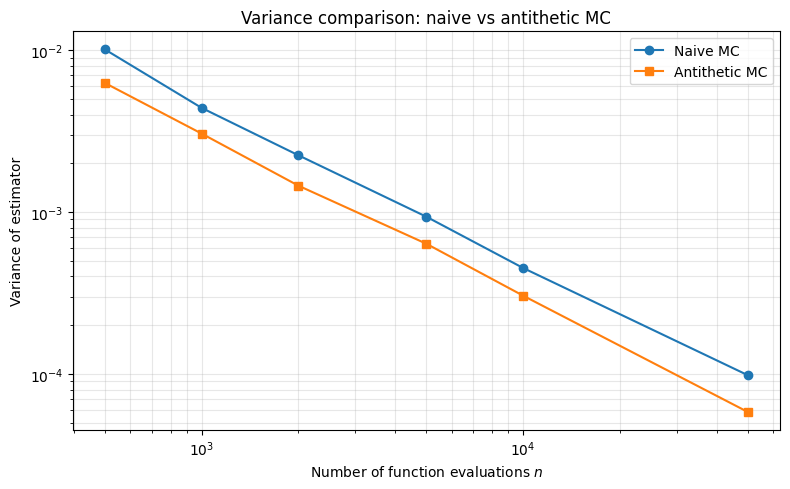

In [10]:
# --- Solution ---
# (a) — answered in markdown:
# When X > 0, e^X > 1 (large), but e^{-X} < 1 (small). Conversely, when
# X < 0, e^X < 1 but e^{-X} > 1. So when one is above its mean, the other
# tends to be below — they are negatively correlated.
# The method exploits the symmetry of the N(0,1) distribution: if X ~ N(0,1),
# then -X ~ N(0,1) as well, so both X and -X are valid draws from the same
# distribution. Pairing them induces negative correlation in the function
# evaluations, reducing the variance of the average.

# (b)
theta_true = np.exp(0.5)

def naive_mc(n):
    X = np.random.normal(0, 1, size=n)
    return np.exp(X).mean()

def antithetic_mc(n):
    half = n // 2
    X = np.random.normal(0, 1, size=half)
    return ((np.exp(X) + np.exp(-X)) / 2).mean()

n = 100_000
est_naive = naive_mc(n)
est_av = antithetic_mc(n)
print(f"Naive MC (n={n:,}):      {est_naive:.6f}")
print(f"Antithetic MC (n={n:,}): {est_av:.6f}")
print(f"True value:              {theta_true:.6f}")
print()

# (c)
M = 2000
n = 10_000
naive_ests = np.array([naive_mc(n) for _ in range(M)])
av_ests    = np.array([antithetic_mc(n) for _ in range(M)])

var_naive = naive_ests.var()
var_av    = av_ests.var()
vrf = var_naive / var_av

print(f"Variance (naive):      {var_naive:.8f}")
print(f"Variance (antithetic): {var_av:.8f}")
print(f"Variance reduction factor: {vrf:.2f}x")
print()

# (d)
ns = [500, 1000, 2000, 5000, 10_000, 50_000]
M = 1000
var_naive_list = []
var_av_list = []

for n in ns:
    naive_reps = np.array([naive_mc(n) for _ in range(M)])
    av_reps    = np.array([antithetic_mc(n) for _ in range(M)])
    var_naive_list.append(naive_reps.var())
    var_av_list.append(av_reps.var())

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ns, var_naive_list, 'o-', label='Naive MC')
ax.loglog(ns, var_av_list, 's-', label='Antithetic MC')
ax.set_xlabel('Number of function evaluations $n$')
ax.set_ylabel('Variance of estimator')
ax.set_title('Variance comparison: naive vs antithetic MC')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Question 10 — Capstone: Regime-Switching GDP Simulation [10 marks]

This question integrates Markov chains, AR(1) dynamics, DataFrames, and plotting.

A country's quarterly GDP growth follows a regime-switching model. There are three regimes (states):

| State | Label | $\mu$ (drift) | $\rho$ (persistence) | $\sigma$ (shock std dev) |
|-------|----------|------|------|-------|
| 0 | Recession | $-0.5$ | 0.2 | 1.5 |
| 1 | Normal | 0.5 | 0.5 | 0.8 |
| 2 | Boom | 1.5 | 0.3 | 1.0 |

The regime evolves as a Markov chain with transition matrix

$$P = \begin{pmatrix} 0.70 & 0.25 & 0.05 \\ 0.10 & 0.80 & 0.10 \\ 0.05 & 0.30 & 0.65 \end{pmatrix}.$$

Within each regime $s_t$, GDP growth follows an AR(1) process:

$$g_t = (1 - \rho_{s_t})\, \mu_{s_t} + \rho_{s_t}\, g_{t-1} + \sigma_{s_t}\, \varepsilon_t, \qquad \varepsilon_t \sim N(0,1).$$

**(a)** [2 marks] Write a function `simulate_regime(P, T, s0=1)` that simulates the Markov chain for $T$ periods starting from state `s0`. Do **not** use `quantecon` — implement the simulation manually using `np.random.choice` with the appropriate row of $P$ as probabilities at each step. Return an integer array of states.

**(b)** [3 marks] Write a function `simulate_gdp(states, params, g0=0.0)` where `params` is a dict or array of $(\mu, \rho, \sigma)$ for each state. Simulate the GDP growth path $g_t$ using the AR(1) formula above. Then compute the GDP level path starting from $\text{GDP}_0 = 100$:
$$\text{GDP}_t = \text{GDP}_{t-1} \times \bigl(1 + g_t / 100\bigr).$$
Store the results (period, state, growth, GDP level) in a pandas DataFrame and return it.

**(c)** [3 marks] Simulate $T = 500$ periods. Produce a two-panel figure:
- **Top panel:** GDP level over time, with background shading indicating the regime (e.g., light red for recession, white for normal, light green for boom).
- **Bottom panel:** GDP growth rate over time (line plot), again with regime shading.

Add a legend identifying the shaded regions.

**(d)** [2 marks] From your simulation, compute the empirical fraction of time spent in each state and the empirical mean growth rate in each state. Compute the theoretical stationary distribution of the Markov chain by finding the left eigenvector of $P$ corresponding to eigenvalue 1 (or by solving $\pi P = \pi$). Compare the empirical and theoretical stationary distributions. Compute the overall long-run average growth rate from the stationary distribution and compare to the simulated average.

Test regime path: [1 1 1 0 0 2 1 1 1 1 0 0 2 2 2 1 1 0 1 1]



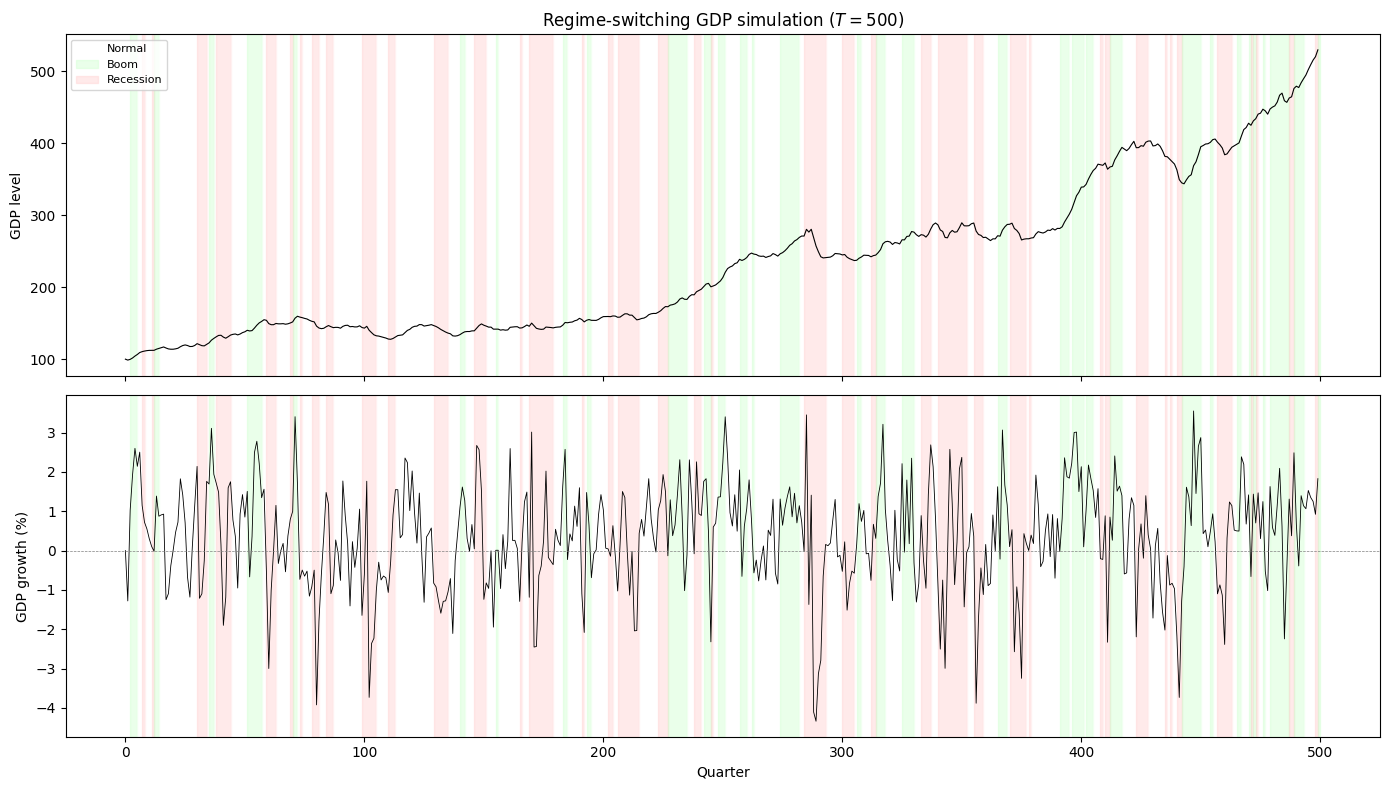

=== Empirical results ===
  Recession   : fraction = 0.2840, mean growth = -0.4065%
  Normal      : fraction = 0.5020, mean growth = 0.3771%
  Boom        : fraction = 0.2140, mean growth = 1.2573%
  Overall simulated mean growth: 0.3429%

=== Theoretical stationary distribution ===
  Recession   : pi = 0.2254
  Normal      : pi = 0.5775
  Boom        : pi = 0.1972
  Theoretical long-run mean growth: 0.4718%

=== Comparison ===
  Empirical fractions:  [0.284 0.502 0.214]
  Stationary dist:      [0.2254 0.5775 0.1972]
  Simulated mean growth: 0.3429%
  Theoretical mean growth: 0.4718%


In [11]:
# --- Solution ---
# (a)
def simulate_regime(P, T, s0=1):
    """Simulate a Markov chain manually using np.random.choice."""
    n_states = P.shape[0]
    states = np.zeros(T, dtype=int)
    states[0] = s0
    for t in range(1, T):
        states[t] = np.random.choice(n_states, p=P[states[t-1]])
    return states

P = np.array([[0.70, 0.25, 0.05],
              [0.10, 0.80, 0.10],
              [0.05, 0.30, 0.65]])

# Quick test
test_states = simulate_regime(P, 20, s0=1)
print("Test regime path:", test_states)
print()

# (b)
def simulate_gdp(states, params, g0=0.0):
    """
    Simulate GDP growth and level given a regime path.
    params: dict mapping state -> (mu, rho, sigma)
    """
    T = len(states)
    growth = np.zeros(T)
    gdp_level = np.zeros(T)
    growth[0] = g0
    gdp_level[0] = 100.0

    for t in range(1, T):
        s = states[t]
        mu, rho, sigma = params[s]
        eps = np.random.normal(0, 1)
        growth[t] = (1 - rho) * mu + rho * growth[t-1] + sigma * eps
        gdp_level[t] = gdp_level[t-1] * (1 + growth[t] / 100)

    df = pd.DataFrame({
        'Period': np.arange(T),
        'State': states,
        'Growth': growth,
        'GDP_Level': gdp_level
    })
    return df

params = {
    0: (-0.5, 0.2, 1.5),   # Recession
    1: (0.5,  0.5, 0.8),   # Normal
    2: (1.5,  0.3, 1.0),   # Boom
}
state_labels = {0: 'Recession', 1: 'Normal', 2: 'Boom'}

# (c)
T = 500
np.random.seed(42)
states = simulate_regime(P, T, s0=1)
df_sim = simulate_gdp(states, params)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Shading colours
colors = {0: '#ffcccc', 1: '#ffffff', 2: '#ccffcc'}
shade_labels = {0: 'Recession', 1: 'Normal', 2: 'Boom'}

def add_regime_shading(ax, states, colors):
    """Add background shading for each regime."""
    shaded = {k: False for k in colors}
    t = 0
    while t < len(states):
        s = states[t]
        t_start = t
        while t < len(states) and states[t] == s:
            t += 1
        lbl = shade_labels[s] if not shaded[s] else None
        ax.axvspan(t_start, t, alpha=0.4, color=colors[s], label=lbl)
        shaded[s] = True

# Top panel: GDP level
add_regime_shading(ax1, df_sim['State'].values, colors)
ax1.plot(df_sim['Period'], df_sim['GDP_Level'], 'k-', linewidth=0.8)
ax1.set_ylabel('GDP level')
ax1.set_title('Regime-switching GDP simulation ($T = 500$)')
ax1.legend(loc='upper left', fontsize=8)

# Bottom panel: GDP growth
add_regime_shading(ax2, df_sim['State'].values, colors)
ax2.plot(df_sim['Period'], df_sim['Growth'], 'k-', linewidth=0.6)
ax2.axhline(0, color='grey', ls='--', lw=0.5)
ax2.set_xlabel('Quarter')
ax2.set_ylabel('GDP growth (%)')

plt.tight_layout()
plt.show()

# (d)
print("=== Empirical results ===")
for s in range(3):
    frac = (df_sim['State'] == s).mean()
    mean_g = df_sim.loc[df_sim['State'] == s, 'Growth'].mean()
    print(f"  {state_labels[s]:12s}: fraction = {frac:.4f}, mean growth = {mean_g:.4f}%")
print(f"  Overall simulated mean growth: {df_sim['Growth'].mean():.4f}%")
print()

# Theoretical stationary distribution: solve pi @ P = pi
# Equivalent to finding left eigenvector with eigenvalue 1
eigenvalues, eigenvectors = np.linalg.eig(P.T)
# Find eigenvector for eigenvalue closest to 1
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()  # normalise

print("=== Theoretical stationary distribution ===")
for s in range(3):
    print(f"  {state_labels[s]:12s}: pi = {pi[s]:.4f}")

# Long-run average growth from stationary distribution
# Use unconditional mean of AR(1) in each state = mu
mu_vals = np.array([params[s][0] for s in range(3)])
avg_growth_theory = pi @ mu_vals
print(f"  Theoretical long-run mean growth: {avg_growth_theory:.4f}%")
print()

print("=== Comparison ===")
empirical_fracs = np.array([(df_sim['State'] == s).mean() for s in range(3)])
print("  Empirical fractions: ", np.round(empirical_fracs, 4))
print("  Stationary dist:     ", np.round(pi, 4))
print(f"  Simulated mean growth: {df_sim['Growth'].mean():.4f}%")
print(f"  Theoretical mean growth: {avg_growth_theory:.4f}%")

*End of Problem Set B.*